# **Practice 17 - Regular Expressions**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [ ]:
# none!

<br>

<br>

<br>

---

####<font color=red>Task 1</font>

<font color=red>Task 1.1</font> For this assignment, we will work with a "clean" version of the movies dataset.

* Load the dataset on movies using the script below.

  ```movies <- read.csv("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/movies_clean.csv")```

* Show the first few lines of the `movies` dataset using the `head()` function

In [1]:
movies <- read.csv("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/movies_clean.csv")

head(movies)

,movie,year,genre
,<chr>,<int>,<chr>
1,Edison Kinetoscopic Record of a Sneeze,1894,"documentary, short"
2,La sortie des usines Lumière,1895,"documentary, short"
3,The Arrival of a Train,1896,"documentary, short"
4,The Oxford and Cambridge University Boat Race,1895,none
5,Le manoir du diable,1896,"short, horror"
6,Une nuit terrible,1896,"short, comedy, horror"


<br>

<font color=red>Task 1.2</font>

* Use the `str()` function to determine the number of rows and columns in the data frame

In [2]:
str(movies)

'data.frame':	37342 obs. of  3 variables:
 $ movie: chr  "Edison Kinetoscopic Record of a Sneeze" "La sortie des usines Lumière" "The Arrival of a Train" "The Oxford and Cambridge University Boat Race" ...
 $ year : int  1894 1895 1896 1895 1896 1896 1902 1903 1903 1908 ...
 $ genre: chr  "documentary, short" "documentary, short" "documentary, short" "none" ...


<br>

<font color=red>Task 1.3</font>

* What information about movies in contained within the data frame? Describe your observations in a text cell.

The movies data frame contains information about films. Each row represents a movie and each column represents an attribute.

<br>

<br>

<br>

---

####<font color=red>Task 2</font>

<font color=red>Task 2.1</font>

* Use `grepl()` to search for all movies that are in the `"western"` genre and store the output as the variable `western_search`

* The output of `grepl()` is which type of data structure?

In [3]:
western_search <- grepl("western", movies$genre, ignore.case = TRUE)

`grepl()` is a logical vector data structure.

<br>

<font color=red>Task 2.2</font>

* Use your `western_search` variable to determine the number of westerns in the dataset.

  Hint: You can use `sum()` since `TRUE` is equivalent to `1` and `FALSE` is equivalent to `0`

In [4]:
sum(western_search)

[1] 530

<br>

<font color=red>Task 2.3</font>

* Use the `grepl()` output from Task 2.1 to extract all rows in the `movies` data frame that are in the `"western"` genre and store as the variable `westerns`

* Show the first few lines the your new `westerns` data frame to verify that each movie is within the `"western"` genre

In [5]:
westerns <- movies[western_search, ]

head(westerns)

,movie,year,genre
,<chr>,<int>,<chr>
8,The Great Train Robbery,1903,"short, action, crime, western"
68,The Mark of Zorro,1920,"adventure, romance, western"
110,The Iron Horse,1924,"history, romance, western"
122,West of Hot Dog,1924,"short, western, comedy"
130,Greed,1924,"drama, thriller, western"
150,3 Bad Men,1926,"romance, western"


<br>

<font color=red>Task 2.4</font>

Let's explore the frequency of westerns over time.

* Use the `table()` function on the `year` variable to count the number of westerns released each year

* Convert this table to a data frame and store this table as the variable `western_frequency`

* Rename the columns of the `western_frequency` data frame to `"year"` and `"count"`

In [6]:
# number of westerns per year
western_frequency <- table(westerns$year)

# convert to data frame
western_frequency <- as.data.frame(western_frequency)

# rename columns
colnames(western_frequency) <- c("year", "count")

# view result
head(western_frequency)

,year,count
,<fct>,<int>
1,1903,1
2,1920,1
3,1924,3
4,1926,2
5,1928,1
6,1930,2


<br>

<font color=red>Task 2.5</font>

* Convert the `year` column from the `western_frequency` data frame into a numeric vector using the following script:

  `as.numeric(as.character(western_frequency$year))`

* Make sure to overwrite your previous `year` column

In [7]:
western_frequency$year <- as.numeric(as.character(western_frequency$year))

<br>

<font color=red>Task 2.6</font>

* Plot a scatterplot with `count` on the y-axis and `year` on the x-axis

    Hint:
    * `plot(x, y, type = "o", pch = 16)`
    * `type = "o"` plots a line with points
    * `pch = 16` uses a solid point as the plotting character

* When were western films most popular?

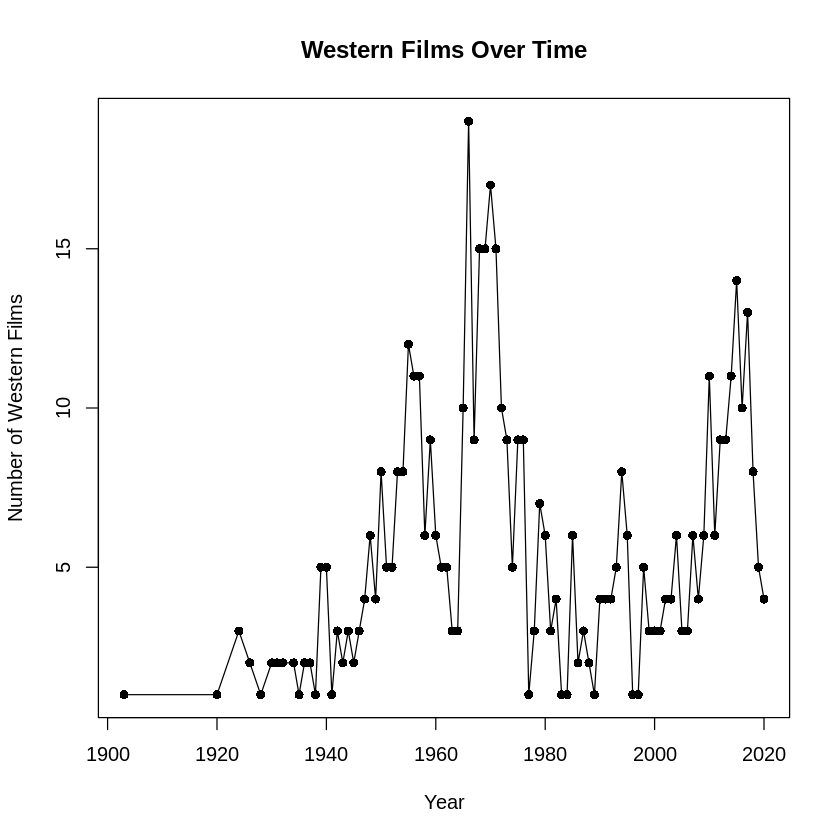

In [8]:
plot(western_frequency$year, western_frequency$count,
     type = "o",
     pch = 16,
     xlab = "Year",
     ylab = "Number of Western Films",
     main = "Western Films Over Time")

Western films were most popular between the years 1965 - 1970's.

<br>

<br>

<br>

---

####<font color=red>Task 3</font>

<font color=red>Task 3.1</font>

* Create another plot similar to Task 2.6 but with the `documentary` movie genre

* What are your observations?
    * When were documentaries most popular?
    * Compare your observations with those of the plot on westerns

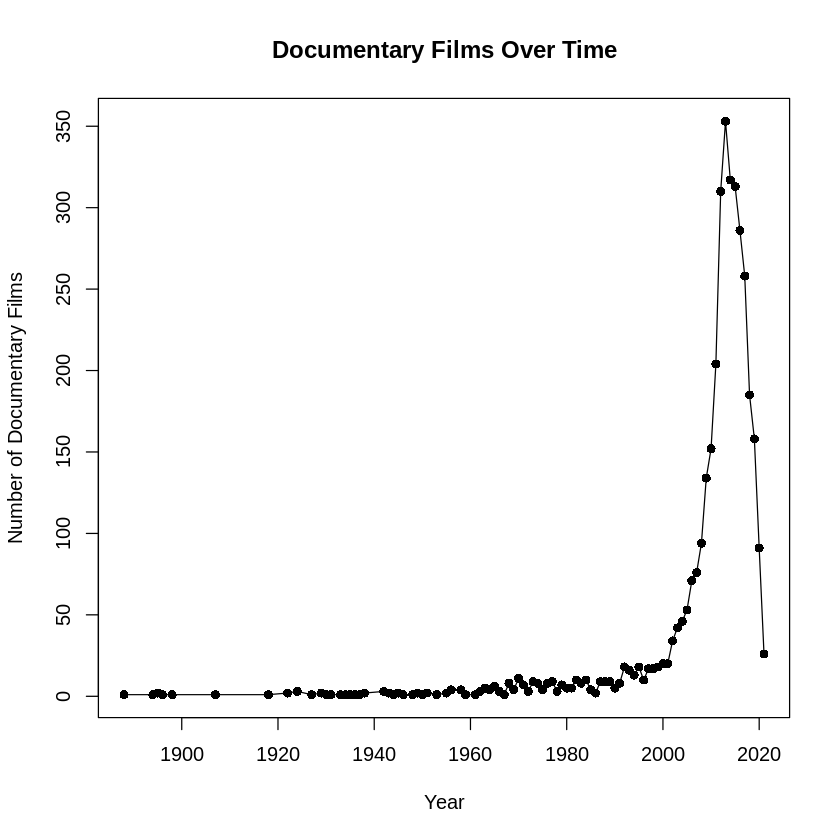

In [9]:
# documentary search
doc_search <- grepl("documentary", movies$genre, ignore.case = TRUE)

# subset data
documentaries <- movies[doc_search, ]

# count per year
doc_frequency <- table(documentaries$year)

# convert to data frame
doc_frequency <- as.data.frame(doc_frequency)

# rename of columns
colnames(doc_frequency) <- c("year", "count")

# convert year to numeric
doc_frequency$year <- as.numeric(as.character(doc_frequency$year))

# plot
plot(doc_frequency$year, doc_frequency$count,
     type = "o",
     pch = 16,
     xlab = "Year",
     ylab = "Number of Documentary Films",
     main = "Documentary Films Over Time")

Documentaries were most popular between the years 2000's - 2010's. In comparison to the plot on westerns, they were more popular in the mid 1900's.

<br>

<br>

<br>

---

####<font color=red>Task 4</font> Exploring with Regular Expressions

<font color=red>Task 4.1</font>

* Use `grepl()` to determine if there are any movies in the `"documentary"`, `"comedy"`, AND `"horror"` genres

  Hint: `grepl(...) & grepl(...) & grepl(...)`

In [10]:
multi_genre_search <- grepl("documentary", movies$genre, ignore.case = TRUE) &
                      grepl("comedy", movies$genre, ignore.case = TRUE) &
                      grepl("horror", movies$genre, ignore.case = TRUE)

In [11]:
sum(multi_genre_search)

[1] 3

<br>

<font color=red>Task 4.2</font>

* Search for all movies where the title starts with a number. You may use either `grepl()` or `grep()`.

* Show the first few movie titles

In [14]:
colnames(movies)

[1] "movie" "year"  "genre"

In [15]:
number_titles <- grepl("^[0-9]", movies$movie)

head(movies$movie[number_titles])

[1] "20,000 Leagues Under the Sea" "45 Minutes from Hollywood"   
[3] "3 Bad Men"                    "42nd Street"                 
[5] "49th Parallel"                "13 Rue Madeleine"

<br>

<font color=red>Task 4.3</font>

* Search for all movies where the title starts with a number OR ends with a number using the `"|"` operator for regular expressions. <br> You may use either `grepl()` or `grep()`.

* Show the first few movie titles

In [16]:
number_titles <- grepl("^[0-9]|[0-9]$", movies$movie)

head(movies$movie[number_titles])

[1] "20,000 Leagues Under the Sea" "45 Minutes from Hollywood"   
[3] "3 Bad Men"                    "The Hollywood Revue of 1929" 
[5] "Under 18"                     "42nd Street"

<br>

<font color=red>Task 4.4</font>

* Search for all movies where
  * the title starts with a capital letter between `"R"` and `"Z"`
  * followed by zero or more of any character
  * ends with a 4-digit number

* Show the first few titles

In [17]:
rz_titles <- grepl("^[R-Z].*[0-9]{4}$", movies$movie)

head(movies$movie[rz_titles])

[1] "The Hollywood Revue of 1929"                                  
[2] "Terror from the Year 5000"                                    
[3] "The Making of the President 1960"                             
[4] "Une femme mariée: Suite de fragments d'un film tourné en 1964"
[5] "THX 1138"                                                     
[6] "Transylvania 6-5000"

<br>

<font color=red>Task 4.5</font>

* Create three other regular expressions that search through the list of movie titles

In [18]:
# 1. titles that contain the word "friend"
friend_titles <- grepl("friend", movies$movie, ignore.case = TRUE)
head(movies$movie[friend_titles])

# 2. titles that end with a question mark
question_titles <- grepl("\\?$", movies$movie)
head(movies$movie[question_titles])

# 3. titles that start with "The"
the_titles <- grepl("^The", movies$movie)
head(movies$movie[the_titles])

[1] "My Learned Friend"          "The Passionate Friends"    
[3] "Friendly Persuasion"        "The Friends of Eddie Coyle"
[5] "Girlfriends"                "Deadly Friend"

[1] "Should Married Men Go Home?" "Why Be Good?"               
[3] "What Price Hollywood?"       "Remember Last Night?"       
[5] "Where's That Fire?"          "How High Is Up?"

[1] "The Arrival of a Train"                       
[2] "The Oxford and Cambridge University Boat Race"
[3] "The Great Train Robbery"                      
[4] "The Adventures of Dollie"                     
[5] "The Country Doctor"                           
[6] "The Lonedale Operator"